## 1. Instalação e Importação de Bibliotecas

In [1]:
import os
import sys
import warnings
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_squared_log_error, r2_score, mean_absolute_error
from sklearn.model_selection import learning_curve, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBRegressor

sys.path.insert(0, '.')
from pipeline import AmesFeatureEngineer

%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted")
warnings.filterwarnings('ignore')
plt.rcParams.update({"figure.figsize": (12, 6), "axes.labelsize": 12, "axes.titlesize": 14})

dirs = ["data/raw", "data/processed", "artifacts", "plots"]
for d in dirs:
    os.makedirs(d, exist_ok=True)

print("✅ Ambiente configurado e pastas criadas.")

✅ Ambiente configurado e pastas criadas.


## 2. Carregamento e Preparação dos Dados

In [2]:
print("[INFO] Carregando dados...")
df_original = pd.read_csv('data/raw/treino.csv')

# Processamento isolado para exportação (Gold Zone)
engineer = AmesFeatureEngineer()
df_tratado = engineer.transform(df_original)
df_tratado.to_csv('data/processed/treino_engineered_clean.csv', index=False)

# Split Treino/Validação
X = df_original.drop(columns=['Id', 'SalePrice'], errors='ignore')
y = df_original['SalePrice']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"✅ Dados preparados. Formato Treino: {X_train.shape}")

[INFO] Carregando dados...
✅ Dados preparados. Formato Treino: (934, 79)


## 3. Análise Exploratória de Dados (EDA)


[INFO] Gerando visualizações...


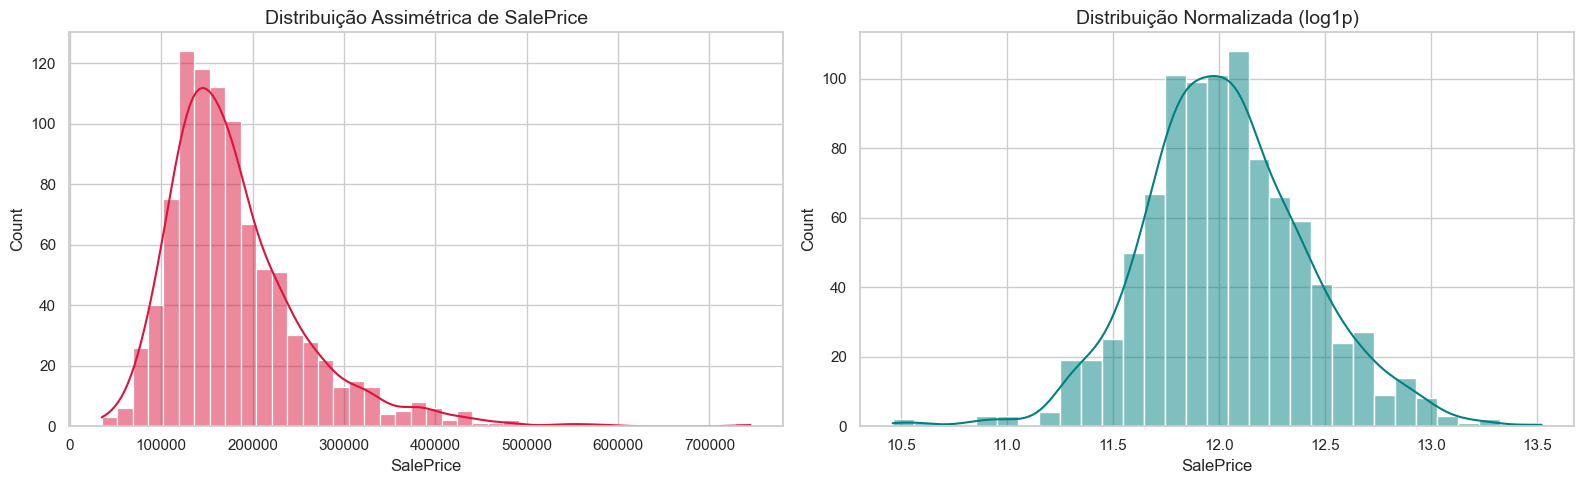

2026-05-25 15:03:20 - INFO - [update] - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-25 15:03:20 - INFO - [update] - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


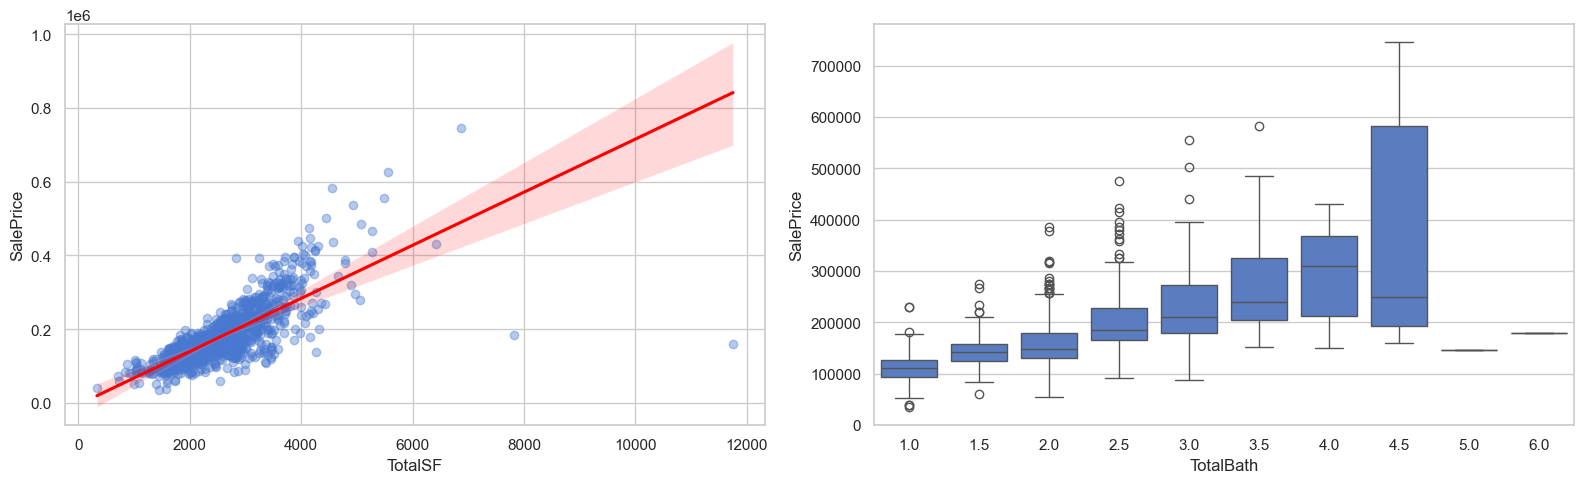

In [3]:
print("[INFO] Gerando visualizações...")

# Distribuição do Alvo
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(y_train, kde=True, ax=axes[0], color='crimson')
axes[0].set_title("Distribuição Assimétrica de SalePrice")

sns.histplot(np.log1p(y_train), kde=True, ax=axes[1], color='teal')
axes[1].set_title("Distribuição Normalizada (log1p)")
plt.tight_layout()
plt.savefig('plots/eda_target_distribution.png')
plt.show()

# Novas Features vs Preço
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.regplot(data=df_tratado, x='TotalSF', y='SalePrice', ax=axes[0], scatter_kws={'alpha':0.4}, line_kws={'color':'red'})
sns.boxplot(data=df_tratado, x='TotalBath', y='SalePrice', ax=axes[1])
plt.tight_layout()
plt.savefig('plots/eda_engineered_features.png')
plt.show()

## 4. Pipeline de Modelagem e Treinamento

In [4]:
print("[INFO] Construindo o Pré-processador...")

# Pipeline para variáveis numéricas: Imputação pela mediana + Escalonamento
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline para variáveis categóricas: Imputação por constante + OneHotEncoding seguro
categorical_transformer = Pipeline(steps=[
    # fill_value='None' garante que casas sem piscina/porão virem uma categoria válida ("None")
    ('imputer', SimpleImputer(strategy='constant', fill_value='None')),
    # handle_unknown='ignore' ignora categorias na base de teste que não existiam no treino
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combinando ambos no ColumnTransformer com seleção DINÂMICA
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, make_column_selector(dtype_include=['int64', 'float64'])),
        ('cat', categorical_transformer, make_column_selector(dtype_include=['object', 'category']))
    ],
    remainder='drop' # Garante que colunas lixo ou não mapeadas sejam ignoradas
)

print("[INFO] Pré-processador pronto para ser acoplado aos modelos.")

[INFO] Construindo o Pré-processador...
[INFO] Pré-processador pronto para ser acoplado aos modelos.


In [5]:

from sklearn.linear_model import Ridge, LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_validate, RandomizedSearchCV
from sklearn.metrics import make_scorer

# Função auxiliar para garantir o mesmo esquema de engenharia + pré-processamento
def montar_pipeline(modelo):
    return Pipeline(steps=[
        ('feature_engineering', AmesFeatureEngineer()),
        ('preprocessor', preprocessor),
        ('regressor', TransformedTargetRegressor(
            regressor=modelo,
            func=np.log1p,
            inverse_func=np.expm1
        ))
    ])

# Scorers para avaliação consistente

def rmsle_metric(y_true, y_pred):
    y_pred = np.clip(y_pred, 0, None)
    return np.sqrt(mean_squared_log_error(y_true, y_pred))

scoring = {
    'r2': 'r2',
    'mae': 'neg_mean_absolute_error',
    'rmsle': make_scorer(rmsle_metric, greater_is_better=False)
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

modelos_base = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=10.0, random_state=42),
    'RandomForest': RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),
    'XGBoost': XGBRegressor(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.85,
        colsample_bytree=0.75,
        reg_alpha=0.0,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1
    )
}

resultados = []

for nome, estimador in modelos_base.items():
    print(f"\n[INFO] Avaliando {nome} com validação cruzada...")
    pipe = montar_pipeline(estimador)
    cv_out = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )
    
    resultados.append({
        'modelo': nome,
        'r2_medio': cv_out['test_r2'].mean(),
        'r2_desvio': cv_out['test_r2'].std(),
        'rmsle_medio': -cv_out['test_rmsle'].mean(),
        'rmsle_desvio': cv_out['test_rmsle'].std(),
        'mae_medio_dolares': -cv_out['test_mae'].mean(),
        'mae_desvio': cv_out['test_mae'].std(),
        'tempo_treino_medio_s': cv_out['fit_time'].mean(),
    })

df_comparacao = pd.DataFrame(resultados).sort_values(by='rmsle_medio')
df_comparacao



[INFO] Avaliando LinearRegression com validação cruzada...

[INFO] Avaliando Ridge com validação cruzada...

[INFO] Avaliando RandomForest com validação cruzada...

[INFO] Avaliando XGBoost com validação cruzada...


,modelo,r2_medio,r2_desvio,rmsle_medio,rmsle_desvio,mae_medio_dolares,mae_desvio,tempo_treino_medio_s
3,XGBoost,0.876802,0.071834,0.124437,0.026196,15155.614063,2250.034217,0.931811
2,RandomForest,0.854367,0.057830,0.140376,0.021370,17380.273363,1881.984009,2.031598
1,Ridge,0.174859,1.329134,0.151359,0.035751,18657.952625,2456.818665,0.034496
0,LinearRegression,0.253883,1.025050,0.177526,0.039898,19008.886909,2883.878619,0.046431


In [6]:
# Busca de hiperparâmetros no candidato com melhor desempenho médio em RMSLE
modelo_escolhido = df_comparacao.iloc[0]['modelo']
print(f"[INFO] Modelo com melhor RMSLE médio: {modelo_escolhido}")

if modelo_escolhido == 'XGBoost':
    espaco_parametros = {
        'regressor__regressor__n_estimators': [300, 400, 500, 650],
        'regressor__regressor__max_depth': [3, 4, 5, 6],
        'regressor__regressor__learning_rate': [0.03, 0.05, 0.08, 0.1],
        'regressor__regressor__subsample': [0.75, 0.85, 0.95],
        'regressor__regressor__colsample_bytree': [0.65, 0.75, 0.85],
        'regressor__regressor__min_child_weight': [1, 3, 5],
        'regressor__regressor__reg_alpha': [0.0, 0.1, 0.5],
        'regressor__regressor__reg_lambda': [0.8, 1.0, 1.5],
    }
    busca_base = montar_pipeline(XGBRegressor(random_state=42, n_jobs=-1))
else:
    espaco_parametros = {
        'regressor__regressor__alpha': [0.1, 1.0, 5.0, 10.0, 25.0, 50.0]
    }
    busca_base = montar_pipeline(Ridge(random_state=42))

busca = RandomizedSearchCV(
    estimator=busca_base,
    param_distributions=espaco_parametros,
    n_iter=15,
    scoring='neg_root_mean_squared_log_error',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

busca.fit(X_train, y_train)

print("[INFO] Melhor conjunto de hiperparâmetros encontrado:")
print(busca.best_params_)
print(f"[INFO] Melhor RMSLE CV: {-busca.best_score_:.5f}")

melhor_pipeline = busca.best_estimator_
y_pred = melhor_pipeline.predict(X_val)

# Exportação do artefato final
joblib.dump(melhor_pipeline, 'artifacts/modelo.pkl')

metricas_holdout = {
    'R2': r2_score(y_val, y_pred),
    'RMSLE': np.sqrt(mean_squared_log_error(y_val, np.clip(y_pred, 0, None))),
    'MAE': mean_absolute_error(y_val, y_pred)
}

metricas_holdout


[INFO] Modelo com melhor RMSLE médio: XGBoost
Fitting 5 folds for each of 15 candidates, totalling 75 fits
[INFO] Melhor conjunto de hiperparâmetros encontrado:
{'regressor__regressor__subsample': 0.85, 'regressor__regressor__reg_lambda': 1.5, 'regressor__regressor__reg_alpha': 0.1, 'regressor__regressor__n_estimators': 500, 'regressor__regressor__min_child_weight': 1, 'regressor__regressor__max_depth': 4, 'regressor__regressor__learning_rate': 0.03, 'regressor__regressor__colsample_bytree': 0.75}
[INFO] Melhor RMSLE CV: 0.12351


{'R2': 0.8858026266098022,
 'RMSLE': np.float64(0.13261591864359495),
 'MAE': 16196.3427734375}

###   Resultados Finais e Escolha do Modelo

Após a validação cruzada, o modelo que apresentou a melhor relação de métricas foi o **XGBoost**.

**Melhores Hiperparâmetros encontrados no Tuning:**
`{'regressor__regressor__subsample': 0.85, 'regressor__regressor__reg_lambda': 1.5, 'regressor__regressor__reg_alpha': 0.1, 'regressor__regressor__n_estimators': 500, 'regressor__regressor__min_child_weight': 1, 'regressor__regressor__max_depth': 4, 'regressor__regressor__learning_rate': 0.03, 'regressor__regressor__colsample_bytree': 0.75}`

####  Tabela Comparativa de Desempenho dos Modelos

*Abaixo, as métricas de validação cruzada. Cores mais fortes indicam melhores resultados (menor RMSLE, maior R2).*

,modelo,r2_medio,r2_desvio,rmsle_medio,rmsle_desvio,mae_medio_dolares,mae_desvio,tempo_treino_medio_s
3,XGBoost,0.87680,0.071834,0.12444,0.026196,"$15,155.61",2250.034217,0.93s
2,RandomForest,0.85437,0.057830,0.14038,0.021370,"$17,380.27",1881.984009,2.03s
1,Ridge,0.17486,1.329134,0.15136,0.035751,"$18,657.95",2456.818665,0.03s
0,LinearRegression,0.25388,1.025050,0.17753,0.039898,"$19,008.89",2883.878619,0.05s


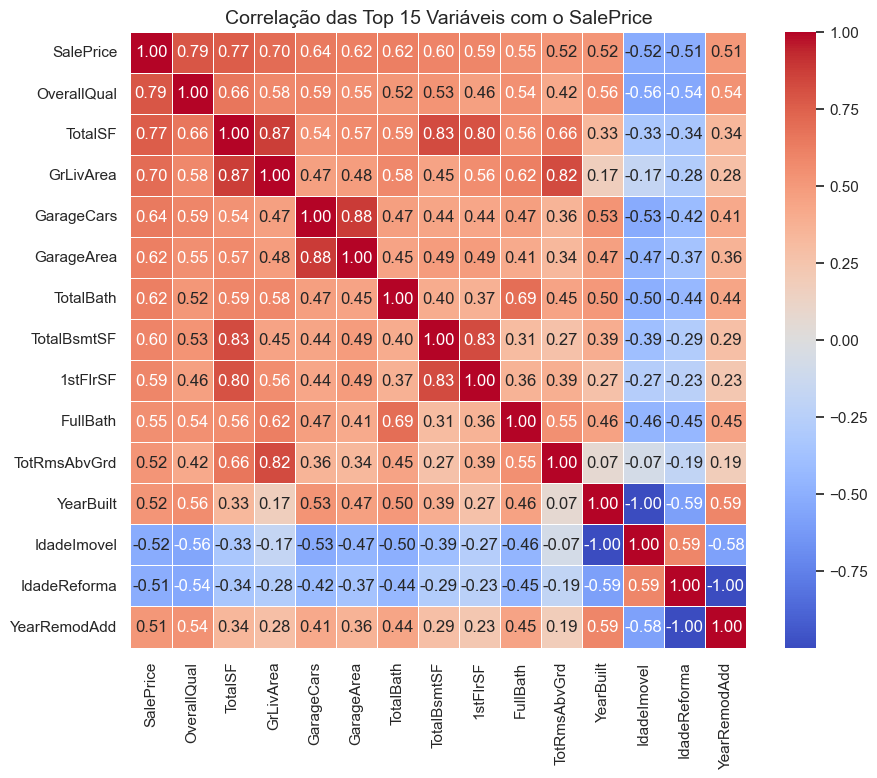

####  Avaliação na Base de Teste (Holdout)

- **R² (Poder de Explicação):** `0.8858` *(o modelo explica 88.6% da variação dos preços)*

- **RMSLE (Métrica da Competição):** `0.13262`

- **Erro Médio Absoluto (MAE):** Erramos os preços em média por **$16,196.34**

In [7]:
import seaborn as sns
import pandas as pd
from IPython.display import display, Markdown

# 1. Exibição clara e explicativa do Modelo Escolhido e Parâmetros
display(Markdown("###   Resultados Finais e Escolha do Modelo"))
display(Markdown(f"Após a validação cruzada, o modelo que apresentou a melhor relação de métricas foi o **{modelo_escolhido}**."))
display(Markdown(f"**Melhores Hiperparâmetros encontrados no Tuning:**\n`{busca.best_params_}`"))

# 2. Melhorando a tabela de comparação com gradientes de cores e formatação de moeda
display(Markdown("####  Tabela Comparativa de Desempenho dos Modelos"))
display(Markdown("*Abaixo, as métricas de validação cruzada. Cores mais fortes indicam melhores resultados (menor RMSLE, maior R2).*"))

df_comparacao_styled = df_comparacao.style \
    .background_gradient(cmap='RdYlGn_r', subset=['rmsle_medio']) \
    .background_gradient(cmap='RdYlGn', subset=['r2_medio']) \
    .format({
        'rmsle_medio': '{:.5f}', 
        'r2_medio': '{:.5f}', 
        'mae_medio_dolares': '${:,.2f}', # Formata o erro absoluto como moeda ($)
        'tempo_treino_medio_s': '{:.2f}s'
    })

display(df_comparacao_styled)

correlation_matrix = df_tratado.corr(numeric_only=True).abs()

cols_selecionadas = correlation_matrix.nlargest(15, 'SalePrice')['SalePrice'].index
correlation_top = df_tratado[cols_selecionadas].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_top, annot=True, cmap='coolwarm', linewidths=.5, square=True, fmt='.2f')
plt.title("Correlação das Top 15 Variáveis com o SalePrice")
plt.savefig('plots/eda_correlation.png')
plt.show()

# 3. Explicação Textual do Holdout
display(Markdown("####  Avaliação na Base de Teste (Holdout)"))
display(Markdown(f"- **R² (Poder de Explicação):** `{metricas_holdout['R2']:.4f}` *(o modelo explica {metricas_holdout['R2']*100:.1f}% da variação dos preços)*"))
display(Markdown(f"- **RMSLE (Métrica da Competição):** `{metricas_holdout['RMSLE']:.5f}`"))
display(Markdown(f"- **Erro Médio Absoluto (MAE):** Erramos os preços em média por **${metricas_holdout['MAE']:,.2f}**"))